In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import plotly.express as px
import os
import io

print("Packages imported successfully!")

Packages imported successfully!


In [4]:
df = pd.read_csv('vehicles_us.csv')
df_cleaned = df.copy()
df.head(10)

,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed
0,9400,2011.0,bmw x5,good,6.0,gas,145000.0,automatic,SUV,NaN,1.0,2018-06-23,19
1,25500,NaN,ford f-150,good,6.0,gas,88705.0,automatic,pickup,white,1.0,2018-10-19,50
2,5500,2013.0,hyundai sonata,like new,4.0,gas,110000.0,automatic,sedan,red,NaN,2019-02-07,79
3,1500,2003.0,ford f-150,fair,8.0,gas,NaN,automatic,pickup,NaN,NaN,2019-03-22,9
4,14900,2017.0,chrysler 200,excellent,4.0,gas,80903.0,automatic,sedan,black,NaN,2019-04-02,28
5,14990,2014.0,chrysler 300,excellent,6.0,gas,57954.0,automatic,sedan,black,1.0,2018-06-20,15
6,12990,2015.0,toyota camry,excellent,4.0,gas,79212.0,automatic,sedan,white,NaN,2018-12-27,73
7,15990,2013.0,honda pilot,excellent,6.0,gas,109473.0,automatic,SUV,black,1.0,2019-01-07,68
8,11500,2012.0,kia sorento,excellent,4.0,gas,104174.0,automatic,SUV,NaN,1.0,2018-07-16,19
9,9200,2008.0,honda pilot,excellent,NaN,gas,147191.0,automatic,SUV,blue,1.0,2019-02-15,17


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51525 entries, 0 to 51524
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         51525 non-null  int64  
 1   model_year    47906 non-null  float64
 2   model         51525 non-null  object 
 3   condition     51525 non-null  object 
 4   cylinders     46265 non-null  float64
 5   fuel          51525 non-null  object 
 6   odometer      43633 non-null  float64
 7   transmission  51525 non-null  object 
 8   type          51525 non-null  object 
 9   paint_color   42258 non-null  object 
 10  is_4wd        25572 non-null  float64
 11  date_posted   51525 non-null  object 
 12  days_listed   51525 non-null  int64  
dtypes: float64(4), int64(2), object(7)
memory usage: 5.1+ MB


The dataset contains several quality issues that need to be addressed to ensure accurate analysis. Missing values are present in key columns such as `model_year`, `cylinders`, and `odometer`, as well as in `paint_color` and `is_4wd`. Additionally, some data types are not ideal — `model_year` is stored as a float but should be an integer, and `is_4wd`, although binary, is a float due to `NaNs`. The dataset also includes potential outliers, such as extremely high or zero values in `price`, and unrealistic `odometer` readings. Furthermore, there are inconsistencies in categorical data: strings in columns like `model`, `condition`, and `paint_color` may have formatting or case issues, which could lead to redundancy or misclassification. Addressing these issues through preprocessing will improve data quality and support more meaningful visualizations and insights.

In [6]:
#Condition
print(df['condition'].unique())
df['condition']

['good' 'like new' 'fair' 'excellent' 'salvage' 'new']


0             good
1             good
2         like new
3             fair
4        excellent
           ...    
51520     like new
51521      salvage
51522    excellent
51523         good
51524         good
Name: condition, Length: 51525, dtype: object

In [7]:
# Full list of original condition types
full_conditions = ['good', 'like new', 'fair', 'excellent', 'salvage', 'new']

# Create a DataFrame using all original condition types
df_full = pd.DataFrame({'condition': full_conditions})

In [8]:
print(df_full['condition'].unique())

['good' 'like new' 'fair' 'excellent' 'salvage' 'new']


In [9]:
# Check for missing values
df['price'].isnull().sum()

0

In [ ]:
# ===== Fill missing values =====

In [10]:
# Fill missing model_year by model median
df['model_year'] = df.groupby('model')['model_year'].transform(lambda x: x.fillna(x.median()))

# Fill cylinders by model median
df['cylinders'] = df.groupby('model')['cylinders'].transform(lambda x: x.fillna(x.median()))

# Fill odometer by model + model_year
df['model_year_str'] = df['model_year'].astype(str)
df['model_yr_key'] = df['model'] + '_' + df['model_year_str']
df['odometer'] = df.groupby('model_yr_key')['odometer'].transform(lambda x: x.fillna(x.median()))

# Drop helper columns
df.drop(columns=['model_year_str', 'model_yr_key'], inplace=True)

In [12]:
price_bounds = (df['price'].quantile(0.01), df['price'].quantile(0.99))
year_bounds = (df['model_year'].quantile(0.01), df['model_year'].quantile(0.99))
df_filtered = df[df['price'].between(*price_bounds) & df['model_year'].between(*year_bounds)]

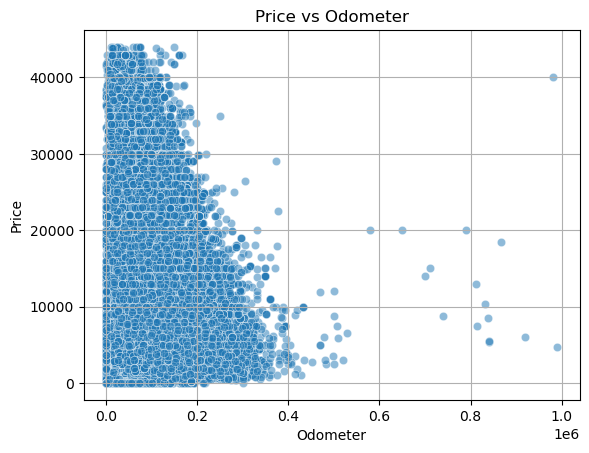

In [13]:
sns.scatterplot(data=df_filtered, x='odometer', y='price', alpha=0.5)
plt.title('Price vs Odometer')
plt.xlabel('Odometer')
plt.ylabel('Price')
plt.grid(True)
plt.show()

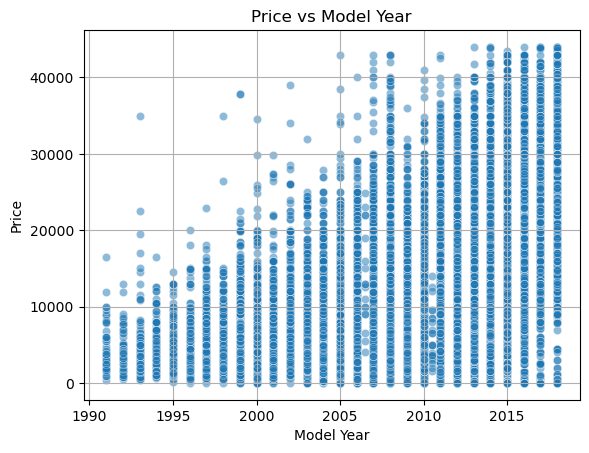

In [14]:
sns.scatterplot(data=df_filtered, x='model_year', y='price', alpha=0.5)
plt.title('Price vs Model Year')
plt.xlabel('Model Year')
plt.ylabel('Price')
plt.grid(True)
plt.show()

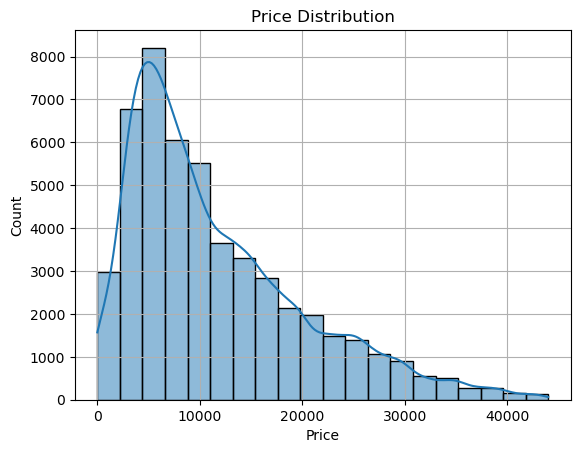

In [15]:
sns.histplot(df_filtered['price'], bins=20, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.grid(True)
plt.show()

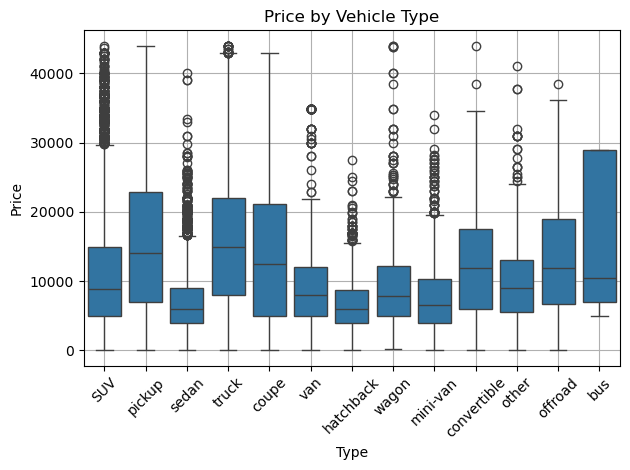

In [18]:
sns.boxplot(data=df_filtered, x='type', y='price')
plt.title('Price by Vehicle Type')
plt.xlabel('Type')
plt.ylabel('Price')
plt.xticks(rotation=45) 
plt.grid(True)
plt.tight_layout() 
plt.show()